# Ejercicio 1.1

---

## Obtención de las Coordenadas en el Biplot

El gráfico biplot superpone dos tipos de información en un mismo plano de dos componentes principales, PC1 y PC2. Sus coordenadas se obtienen:

* **Las observaciones o puntos:** Las obtiene proyectando los datos originales centrados y escalados sobre los 2 mayores vectores propios de la matriz de covarianza.
* **Las variables o vectores:** Sus coordenadas se extraen a partir de los pesos de las componentes principales, que vienen desde las componentes de los vectores propios asociados a la matriz de covarianza empírica (la matrix: 5 × 5 of type dbl).

---

## Interpretación de la Representación

Identificamos 4 aspectos claves a observar que permiten interpretar la visualización del Biplot:

* **1. Ángulo entre vectores:** Grado de correlación entre las variables originales.
    * Flechas en _**direcciones similares**_ > variables con fuerte correlación positiva.
    * Flechas en _**direcciones opuestas**_ > variables con fuerte correlación negativa.
    * Flechas _**perpendiculares**_ > variables no correlacionadas.
    
* **2. Longitud de vectores:** Varianza de la variable original.
    * Una flecha más larga significa que esa variable está muy bien representada en ese plano bidimensional.

* **3. Proximidad de puntos:**
    * _**Puntos cercanos**_ > Observaciones que tienen perfiles de datos similares en las variables analizadas.
    * _**Puntos lejanos**_ > Observaciones que tienen perfiles de datos muy diferentes en las variables analizadas.

* **4. Proyección de puntos:**
    * Si trazamos una línea perpendicular desde un punto (observación) hasta la línea definida por una flecha (variable), podemos estimar el valor relativo de esa observación para esa variable.
    * Las observaciones ubicadas lejos en la misma dirección a la que apunta una flecha tienden a tener valores por encima de la media para esa variable específica.

---



# Ejercicio 1.2

---

## Comparación de Resultados


Al comparar procedimientos, notamos una corrección al momento de obtener los valores con `prcomp`:

```R
pca_res <- prcomp(datos, scale = TRUE)
names(pca_res)
pca_res$sdev
pca_res$rotation <- -pca_res$rotation
pca_res$center
pca_res$scale
pca_res$x <- -pca_res$x
```

Las magnitudes y las proporciones son idénticas, pero _**los signos pueden estar invertidos**_ . Una columna que era positiva en el método manual puede aparecer negativa en `prcomp`. Esto se corrige en el codigo en las líneas:

```R
pca_res$rotation <- -pca_res$rotation
pca_res$x <- -pca_res$x
```


Multiplicar por `-1` no cambia en absoluto la validez del PCA ni las distancias relativas entre los puntos y para este caso particular simplemente rotó el gráfico y en nuestros graficos manuales tambien se hizo en la linea: w <- -mdat.eigen$vectors[,1:2].

La matriz de coovarianzas empiricas tiene los mismos valores en el calculo manual y el calculo por prcomp (se puede ver la matriz si se elimina la linea "**<- -pca_res$rotation**")

---

## Explicación de los componentes del objeto `prcomp`

* **`pca_res$sdev` (Desviaciones estándar de las componentes):**
  * Contiene la desviación estándar asociada a cada componente principal (es decir, la raíz cuadrada de los valores propios de la matriz de covarianza: $\sqrt{\lambda}$).
* **`pca_res$rotation` (Matriz de Rotación / Pesos / Loadings):**
  * Es la matriz de los vectores propios (eigenvectors) o loadings. Representa los coeficientes que multiplican a las variables originales para rotarlas y obtener las componentes principales.
  * Proveen las coordenadas para dibujar las flechas (vectores) en el biplot.
* **`pca_res$center` (Centros):**
  * Es el vector de las medias originales de las variables que se utilizaron para "centrar" los datos en 0 antes del PCA.
* **`pca_res$scale` (Escalas):**
  * Es un vector con las desviaciones estándar de las variables originales.
  * Como se indicó `scale = TRUE`, R dividió los datos centrados por estos valores para estandarizar las varianzas.
* **`pca_res$x` (Puntuaciones / Scores):**
  * Corresponde a la proyección de los datos originales sobre las nuevas componentes principales. Esto equivale al cálculo de la matriz $Xw$, o las variables $Z_j$.
  * Básicamente, son las coordenadas de cada una de las observaciones originales traducidas al nuevo plano bidimensional.
  * Proveen las coordenadas para dibujar los puntos (observaciones) en el biplot.

  ---

# Ejercicio 2.1

---

## Análisis Exploratorio

Primero, cargaremos los datos, eliminaremos las dos últimas columnas (`contaminacion` y `alerta`, como pide el enunciado) y prepararemos el entorno para el análisis exploratorio.

      pm25               no2              trafico             viento         
 Min.   :-3.07318   Min.   :-2.48924   Min.   :-2.42363   Min.   :-2.588918  
 1st Qu.:-0.58922   1st Qu.:-0.62800   1st Qu.:-0.64707   1st Qu.:-0.690654  
 Median :-0.01977   Median :-0.01134   Median :-0.03506   Median : 0.004793  
 Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.000000  
 3rd Qu.: 0.61085   3rd Qu.: 0.52846   3rd Qu.: 0.56590   3rd Qu.: 0.652127  
 Max.   : 3.52134   Max.   : 6.46833   Max.   : 5.34314   Max.   : 3.219595  
               pm25        no2    trafico      viento
pm25    1.000000000 0.21036508 0.18673399 0.004609148
no2     0.210365080 1.00000000 0.20386971 0.048725880
trafico 0.186733988 0.20386971 1.00000000 0.056500986
viento  0.004609148 0.04872588 0.05650099 1.000000000


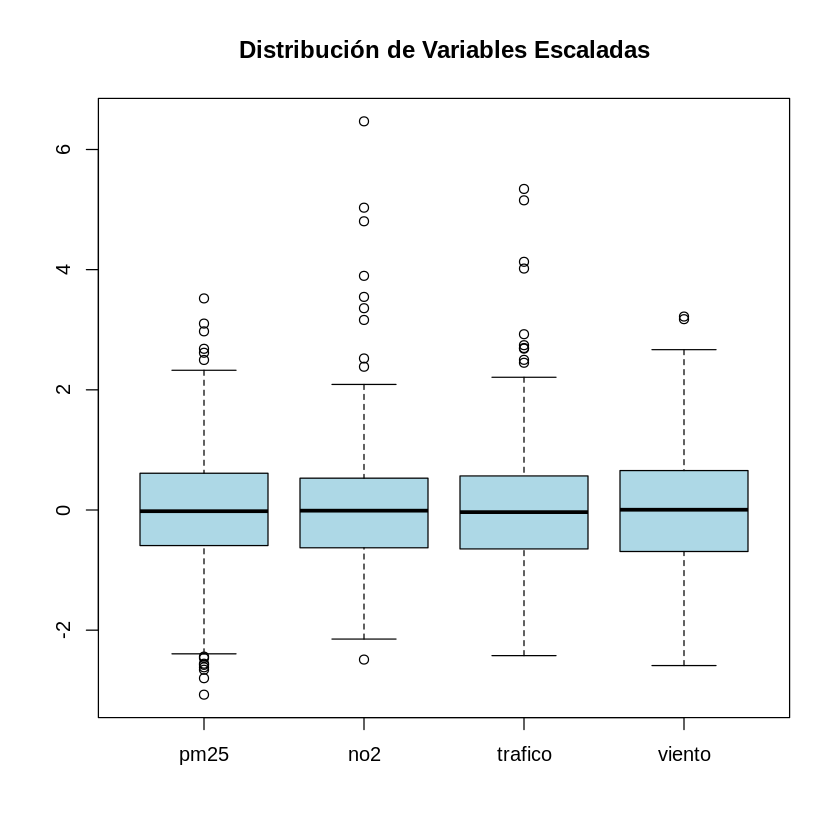

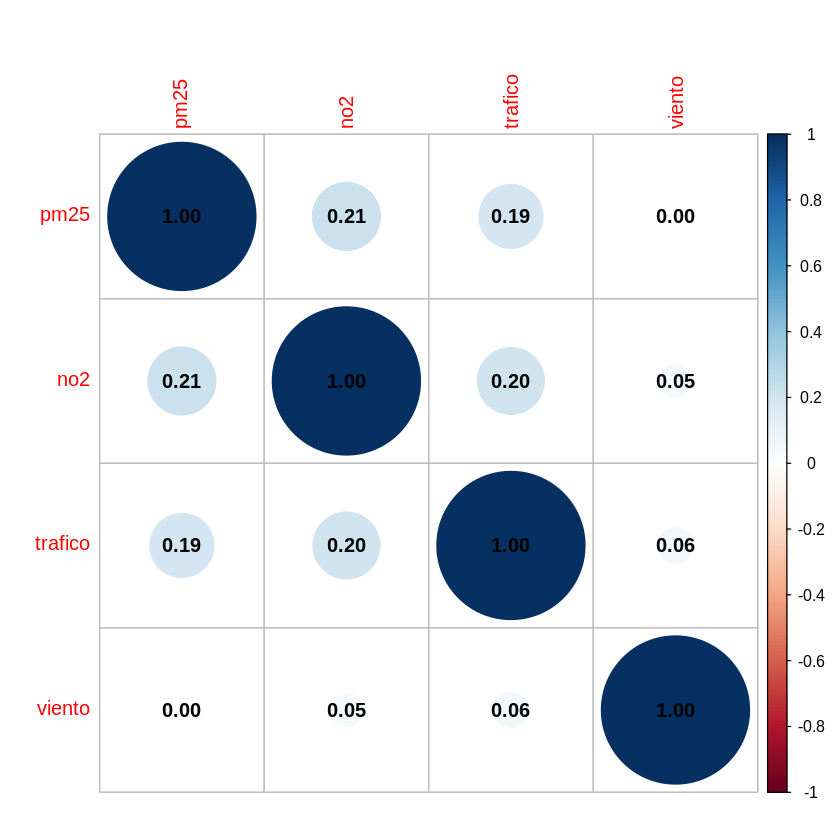

In [12]:
# Carga de datos
datos_originales <- read.csv("/Grupo4.csv", sep=";", dec=".", header=TRUE)

# Extraer todas las columnas salvo las dos ultimas (dejando pm25, no2, trafico, viento)
datos_pca <- datos_originales[, 1:(ncol(datos_originales)-2)]

# Eliminar filas con valores nulos (NA)
datos_pca <- na.omit(datos_pca)

# Escalar los datos (media = 0, varianza = 1)
datos_pca <- scale(datos_pca)
# Convertimos de vuelta a data.frame por si necesitas hacer manipulaciones posteriores
datos_pca <- as.data.frame(datos_pca)

# Resumen estadistico (ahora verás que las medias son 0 o números muy cercanos a 0)
print(summary(datos_pca))

# Boxplots para evaluar dispersion y valores atipicos (ahora estarán en la misma escala)
boxplot(datos_pca, main="Distribución de Variables Escaladas", col="lightblue")

# Matriz de Correlación
if (!require("corrplot")) {
  install.packages("corrplot")
}
library(corrplot) # Corregido: antes decía library(factoextra)

mcor <- cor(datos_pca)
print(mcor)

corrplot(mcor, method="circle", type="full", addCoef.col="black")


## Análisis de Componentes Principales

Importance of components:
                          PC1    PC2    PC3    PC4
Standard deviation     1.1877 0.9991 0.8987 0.8851
Proportion of Variance 0.3527 0.2495 0.2019 0.1958
Cumulative Proportion  0.3527 0.6022 0.8042 1.0000
               PC1         PC2        PC3        PC4
pm25    -0.5592096  0.24796691  0.5453209 -0.5730813
no2     -0.5857478  0.04125002  0.2038172  0.7833623
trafico -0.5661889 -0.02497795 -0.7953183 -0.2151163
viento  -0.1536692 -0.96756754  0.1689747 -0.1079184


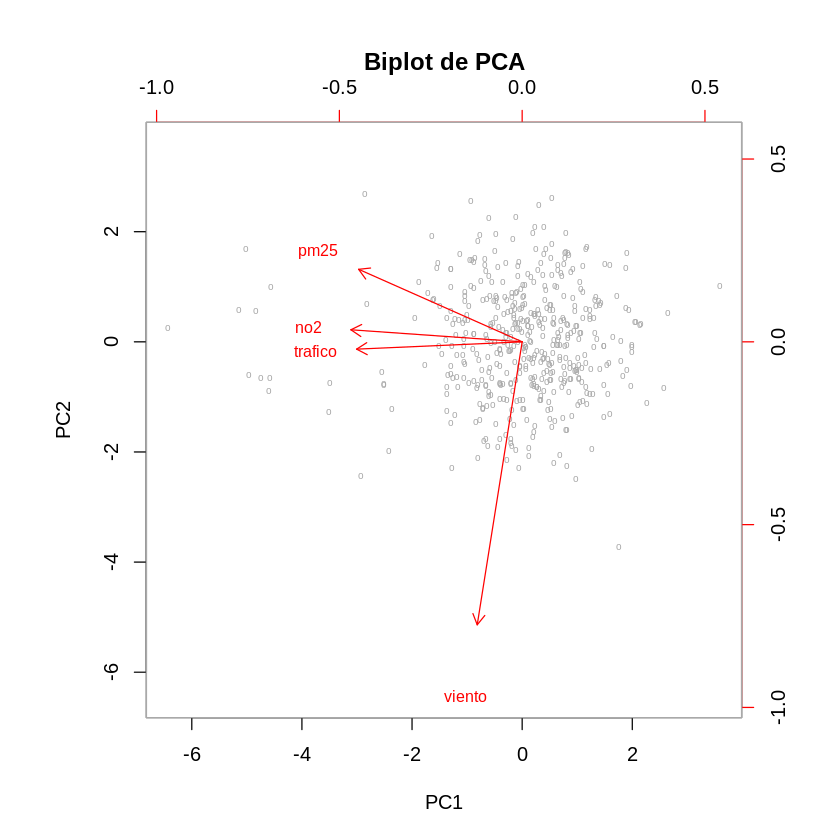

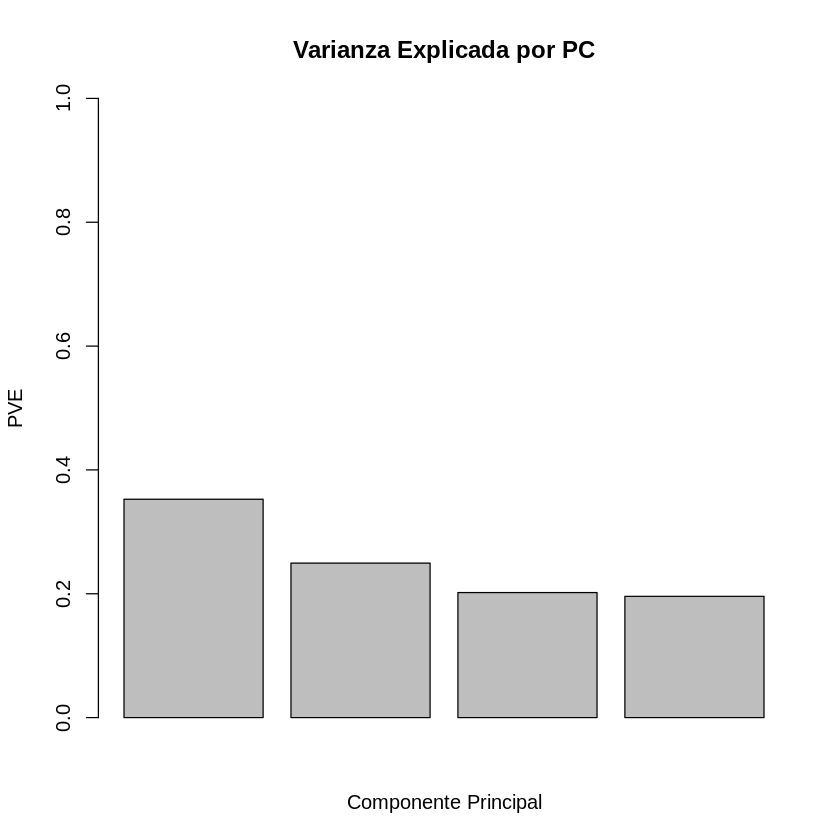

In [13]:
# Ejecutar PCA centrando y escalando los datos
pca_res <- prcomp(datos_pca, scale = TRUE)

# Resumen numerico del PCA (Varianza explicada)
print(summary(pca_res))

# Ver los "pesos" o matriz de rotacion
print(pca_res$rotation)

# Generar el Biplot
biplot(pca_res, scale = 0, cex = c(0.5, 0.8), col = c("darkgray", "red"), main="Biplot de PCA", xlabs = rep('o', nrow(pca_res$x)))

# Calcular y graficar la Proporcion de Varianza Explicada (PVE)
PVE <- pca_res$sdev^2 / sum(pca_res$sdev^2)
barplot(PVE, xlab="Componente Principal", ylab="PVE", main="Varianza Explicada por PC", ylim=c(0, 1))

# Ejercicio 2.2

---

### Interpretación de Resultados

* **Correlaciones:** La matriz de correlación indica que las variables son casi independientes.
    * Existe una correlación positiva relativamente debil (0.20) entre `pm25`, `no2` y `trafico`.
    * La variable `viento` no tiene absolutamente ninguna correlación (0.05) con el resto.
    * Esto al observar el _**biplot**_ se confirma al ver como las flechas de `pm25`, `no2` y `trafico` apuntan vagamente hacia una misma dirección, mientras que la flecha de `viento` apunta en un ángulo casi perpendicular de 90°.

* **Sobre el PCA:** Los resultados de la Proporción de Varianza Explicada (PVE) de tus datos son aproximadamente:
    * **PC1:** 35.3%
    * **PC2:** 25.0%
    * **PC3:** 20.2%
    * **PC4:** 19.6%
    * Como vimos en clases, en un escenario ideal de PCA, la primera componente absorbe el 70% u 80% de la varianza. En los datos analizados, la PC1 solo explica un 35%. Se necesitaría incluir PC1, PC2 y PC3 para alcanzar un 80.5%.
    * En conclusión, este conjunto de datos no es conveniente para una compresión vía PCA.

### ¿Cuál es el interés de utilizar PCA en este conjunto de datos?
Se podría pensar que el PCA "fracasó" porque no logramos una gran reducción de dimensionalidad. Sin embargo, el interés de haber aplicado PCA radica en su **capacidad diagnóstica**. Nos demostró que **no existe una alta correlación** entre las variables de nuestro conjunto de datos. Todas las variables están aportando información mayormente única e independiente (especialmente el viento).

### Sugerencia de limpieza
Al observar los resultados de `summary(datos_pca)`, la variable **`pm25`** tiene un valor mínimo de **-21.73**, y la variable **`no2`** un mínimo de **-10.47**. Físicamente, es imposible tener concentraciones negativas de contaminantes en el aire. Esto podría indicar **errores de medición o de registro en el dataset**.

La limpieza sugerida sería filtrar todas las filas que contengan valores menores a cero en estas variables ambientales.